
# XAI dla GNN na TCGA

Robimy pełny pipeline wyjaśniania dla wytrenowanego GNN na grafach TCGA:

1. ładujemy checkpoint i przetworzone grafy,
2. wykonujemy predykcję dla jednego pacjenta/próbki,
3. propagujemy relevancję **warstwa po warstwie** metodą LRP,
4. mapujemy wartości $R$ na nazwy genów,
5. zapisujemy tabelę i wizualizuje najważniejsze geny.

Wyjaśnienie jest liczone przez lokalne reguły LRP dla warstw liniowych i konwolucyjnych GCN, a następnie przez prosty linear readout (średnia z logitów węzłów). Dzięki temu wynik ma strukturę zgodną z ideą GNN-LRP z pracy Schnake i in.


## Założenia matematyczne

Dla warstwy GCN używamy standardowej postaci

$$
H^{(l+1)} = \sigma(\hat A H^{(l)} W^{(l)\top} + b^{(l)}),
$$

gdzie $\hat A$ to znormalizowana macierz sąsiedztwa z self-loopami.

Dla LRP stosujemy regułę $\varepsilon$ / $\gamma$:

$$
R_i = \sum_j \frac{z_{ij}}{\sum_i z_{ij} + \varepsilon \,\mathrm{sign}(\sum_i z_{ij})}\,R_j,
\qquad
z_{ij} = x_i \left(w_{ij} + \gamma \max(w_{ij}, 0)\right).
$$

Dla readoutu grafowego używamy AttentionalAggregation(pool3) po ostatniej warstwie GCN, a następnie warstwy liniowej. Relevancja z logitu grafowego jest najpierw propagowana przez lrp_linear na embedding grafu, a następnie równomiernie rozłożona na węzły (przybliżenie mean-pooling).

W tym notebooku relevancja z logitu grafowego wraca do węzłów równomiernie przez mean pooling, a potem jest propagowana wstecz przez warstwy GCN.


In [46]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score

from torch.nn import Linear
from torch_geometric.nn import AttentionalAggregation, GCNConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

from torch_geometric.nn.conv.gcn_conv import gcn_norm


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')


## Ścieżki do danych i checkpointu


In [47]:
DATA_DIR = Path("processed_data")
MODEL_PATH = Path("best_gnn_model2.pth")
GENES_PATH = Path("top_genes_list.txt")

TRAIN_PATH = DATA_DIR / "train_dataset.pt"
VAL_PATH   = DATA_DIR / "val_dataset.pt"
TEST_PATH  = DATA_DIR / "test_dataset.pt"
EDGE_PATH  = DATA_DIR / "edge_index.pt"
CLASS_MAP_PATH = DATA_DIR / "class_mapping.npy"

print("All files found")

All files found


In [48]:
# load data
train_dataset = torch.load(TRAIN_PATH, weights_only=False)
val_dataset = torch.load(VAL_PATH, weights_only=False)
test_dataset = torch.load(TEST_PATH, weights_only=False)
edge_index = torch.load(EDGE_PATH, weights_only=False)
class_mapping = np.load(CLASS_MAP_PATH, allow_pickle=True).item()

with open(GENES_PATH, "r", encoding="utf-8") as f:
    genes = [line.strip() for line in f if line.strip()]

print("Train graphs:", len(train_dataset))
print("Val graphs:", len(val_dataset))
print("Test graphs:", len(test_dataset))
print("edge_index shape:", tuple(edge_index.shape))
print("Number of genes:", len(genes))
print("Class mapping:", class_mapping)

num_nodes = test_dataset[0].num_nodes
assert len(genes) == num_nodes, f"Gene list length ({len(genes)}) != number of graph nodes ({num_nodes})"
assert edge_index.shape[0] == 2
assert test_dataset[0].x.shape[1] == 1, "Notebook assumes a single node feature per gene."
print("Sanity checks passed")

Train graphs: 4986
Val graphs: 623
Test graphs: 624
edge_index shape: (2, 11199)
Number of genes: 997
Class mapping: {np.int64(0): 'brain lower grade glioma', np.int64(1): 'breast invasive carcinoma', np.int64(2): 'colon adenocarcinoma', np.int64(3): 'head & neck squamous cell carcinoma', np.int64(4): 'kidney clear cell carcinoma', np.int64(5): 'lung adenocarcinoma', np.int64(6): 'lung squamous cell carcinoma', np.int64(7): 'prostate adenocarcinoma', np.int64(8): 'thyroid carcinoma', np.int64(9): 'uterine corpus endometrioid carcinoma'}
Sanity checks passed


## Model
4 warstwy GCN + AttentionalAggregation (nieużywane w forwardzie) + linear readout

In [49]:
class GNN_Model(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        num_hidden_units = 64

        self.conv0 = GCNConv(num_node_features, num_hidden_units)
        self.conv1 = GCNConv(num_hidden_units, num_hidden_units)
        self.conv2 = GCNConv(num_hidden_units, num_hidden_units)
        self.conv3 = GCNConv(num_hidden_units, num_hidden_units)

        self.pool0 = AttentionalAggregation(Linear(num_hidden_units, 1))
        self.pool1 = AttentionalAggregation(Linear(num_hidden_units, 1))
        self.pool2 = AttentionalAggregation(Linear(num_hidden_units, 1))
        self.pool3 = AttentionalAggregation(Linear(num_hidden_units, 1))

        self.lin = Linear(num_hidden_units, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv0(x, edge_index)
        x = x.relu()
        _ = self.pool0(x, batch)

        x = self.conv1(x, edge_index)
        x = x.relu()
        _ = self.pool1(x, batch)

        x = self.conv2(x, edge_index)
        x = x.relu()
        _ = self.pool2(x, batch)

        x = self.conv3(x, edge_index)
        _ = self.pool3(x, batch)

        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x

    @torch.no_grad()
    def forward_node_logits(self, data: Data):
        data = data.to(device)
        batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
        return self.forward(data.x, data.edge_index, batch)

    @torch.no_grad()
    def forward_graph_logits(self, data: Data):
        """
        Post-hoc graph readout: średnia po logitach węzłów.
        To jest linearne i dzięki temu kompatybilne z LRP.
        """
        data = data.to(device)
        batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
        node_logits = self.forward(data.x, data.edge_index, batch)
        graph_logits = global_mean_pool(node_logits, batch)
        return node_logits, graph_logits

model = GNN_Model(num_node_features=1, num_classes=len(class_mapping)).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded checkpoint from epoch:", checkpoint.get("epoch", "unknown"))
print("Validation F1 stored in checkpoint:", checkpoint.get("val_f1", "unknown"))

Loaded checkpoint from epoch: 85
Validation F1 stored in checkpoint: 0.8433968523809826



## Predykcja i ewaluacja

Dla pojedynczej próbki używam `graph_logits = mean(node_logits)`, bo:
- daje jedną decyzję dla pacjenta,
- jest liniowe,
- da się poprawnie przepuścić przez LRP.


In [50]:
def make_batch_vector(data: Data, device: torch.device) -> torch.Tensor:
    return torch.zeros(data.num_nodes, dtype=torch.long, device=device)

@torch.no_grad()
def predict_graph(model, data: Data):
    """Predykcja zgodna z treningiem i ewaluacją (pool3 + lin)."""
    model.eval()
    data = data.to(device)
    batch = make_batch_vector(data, device)
    
    x = data.x
    x = model.conv0(x, data.edge_index); x = x.relu(); _ = model.pool0(x, batch)
    x = model.conv1(x, data.edge_index); x = x.relu(); _ = model.pool1(x, batch)
    x = model.conv2(x, data.edge_index); x = x.relu(); _ = model.pool2(x, batch)
    x = model.conv3(x, data.edge_index)
    graph_emb = model.pool3(x, batch)
    graph_logits = model.lin(graph_emb)
    
    probs = torch.softmax(graph_logits, dim=-1)[0]
    pred_class = int(probs.argmax().item())
    confidence = float(probs[pred_class].item())
    
    return {
        "graph_logits": graph_logits.detach(),
        "probs": probs.detach(),
        "pred_class": pred_class,
        "confidence": confidence,
    }

In [51]:
def evaluate_loader(loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch_data in loader:
            batch_data = batch_data.to(device)
            
            x = batch_data.x
            x = model.conv0(x, batch_data.edge_index)
            x = x.relu()
            _ = model.pool0(x, batch_data.batch)
            
            x = model.conv1(x, batch_data.edge_index)
            x = x.relu()
            _ = model.pool1(x, batch_data.batch)
            
            x = model.conv2(x, batch_data.edge_index)
            x = x.relu()
            _ = model.pool2(x, batch_data.batch)
            
            x = model.conv3(x, batch_data.edge_index)
            graph_emb = model.pool3(x, batch_data.batch)
            
            graph_logits = model.lin(graph_emb)
            
            preds = graph_logits.argmax(dim=-1)
            y_true.extend(batch_data.y.view(-1).cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    
    return accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro")


val_acc, val_f1 = evaluate_loader(val_loader)
test_acc, test_f1 = evaluate_loader(test_loader)

print(f"Validation Accuracy:  {val_acc:.4f}")
print(f"Validation F1 (macro): {val_f1:.4f}")
print(f"Test Accuracy:         {test_acc:.4f}")
print(f"Test F1 (macro):       {test_f1:.4f}")

Validation Accuracy:  0.8491
Validation F1 (macro): 0.8434
Test Accuracy:         0.8413
Test F1 (macro):       0.8419


## LRP — helpery

Poniższe funkcje robią właściwą propagację relevancji.

- `lrp_linear(...)` — dla warstwy liniowej,
- `lrp_gcn_layer(...)` — dla jednej warstwy GCN zapisanej jako
  $X \mapsto \hat A X W^\top$.

Gamma-rules stosuję do wag dodatnich, zgodnie z ideą Schnake i in.


In [52]:
def _stabilize(x: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    return eps * torch.where(x >= 0, torch.ones_like(x), -torch.ones_like(x))

def lrp_linear(x: torch.Tensor,
               weight: torch.Tensor,
               R_out: torch.Tensor,
               gamma: float = 0.0,
               eps: float = 1e-6) -> torch.Tensor:
    """
    LRP dla warstwy liniowej:
        y = x @ weight.T
    x: [N, Fin]
    weight: [Fout, Fin]
    R_out: [N, Fout]
    """
    Wp = weight + gamma * weight.clamp(min=0.0)

    z = x @ Wp.t()
    s = R_out / (z + _stabilize(z, eps))
    R_in = x * (s @ Wp)

    return R_in

def build_dense_gcn_matrix(edge_index: torch.Tensor, num_nodes: int, dtype=torch.float32, device=None) -> torch.Tensor:
    """
    Buduje gęstą macierz Ĥ znormalizowanej sąsiedztwa używanej przez GCNConv.
    """
    if device is None:
        device = edge_index.device
    edge_weight = torch.ones(edge_index.size(1), dtype=dtype, device=device)
    norm_edge_index, norm_edge_weight = gcn_norm(
        edge_index,
        edge_weight=edge_weight,
        num_nodes=num_nodes,
        add_self_loops=True,
        dtype=dtype,
    )
    A = torch.zeros((num_nodes, num_nodes), dtype=dtype, device=device)
    A.index_put_((norm_edge_index[0], norm_edge_index[1]), norm_edge_weight, accumulate=True)
    return A

def get_gcn_weight(conv: GCNConv) -> torch.Tensor:
    """
    PyG różni się między wersjami, więc pobieram wagę bezpiecznie.
    """
    if hasattr(conv, "lin") and hasattr(conv.lin, "weight"):
        return conv.lin.weight
    if hasattr(conv, "weight"):
        return conv.weight
    raise AttributeError("Could not find GCNConv weight parameter.")

def lrp_gcn_layer(x: torch.Tensor,
                  weight: torch.Tensor,
                  adj_norm: torch.Tensor,
                  R_out: torch.Tensor,
                  gamma: float = 0.1,
                  eps: float = 1e-6) -> torch.Tensor:
    """
    LRP dla warstwy GCN zapisanej jako:
        Y = adj_norm @ (x @ W.T)

    x:        [N, Fin]
    weight:   [Fout, Fin]
    adj_norm: [N, N]
    R_out:    [N, Fout]
    """
    Wp = weight + gamma * weight.clamp(min=0.0)

    support = x @ Wp.t()          # [N, Fout]
    z = adj_norm @ support        # [N, Fout]

    s = R_out / (z + _stabilize(z, eps))
    R_support = support * (adj_norm.t() @ s)

    t = R_support / (support + _stabilize(support, eps))
    R_in = x * (t @ Wp)

    return R_in


## Forward cache i pełna propagacja LRP

Tutaj liczę:
1. predykcję,
2. cache aktywacji po każdej warstwie,
3. relevancję na wejściu każdego genu.

Dla klasyfikacji grafowej używam logitu klasy przewidzianej dla całego pacjenta.


In [53]:
#
@torch.no_grad()
def forward_with_cache(model: GNN_Model, data: Data):
    model.eval()
    data = data.to(device)
    batch = make_batch_vector(data, device)
    adj_norm = build_dense_gcn_matrix(data.edge_index, data.num_nodes, dtype=data.x.dtype, device=device)

    x = data.x
    z1 = model.conv0(x, data.edge_index)
    a1 = F.relu(z1)
    _ = model.pool0(a1, batch)

    z2 = model.conv1(a1, data.edge_index)
    a2 = F.relu(z2)
    _ = model.pool1(a2, batch)

    z3 = model.conv2(a2, data.edge_index)
    a3 = F.relu(z3)
    _ = model.pool2(a3, batch)

    z4 = model.conv3(a3, data.edge_index)
    graph_emb = model.pool3(z4, batch)
    graph_logits = model.lin(graph_emb)

    cache = {
        "x0": x.detach(),
        "z1": z1.detach(),
        "a1": a1.detach(),
        "z2": z2.detach(),
        "a2": a2.detach(),
        "z3": z3.detach(),
        "a3": a3.detach(),
        "z4": z4.detach(),
        "graph_emb": graph_emb.detach(),
        "graph_logits": graph_logits.detach(),
        "batch": batch.detach(),
        "adj_norm": adj_norm.detach(),
    }
    return cache

#
def explain_sample_lrp(model: GNN_Model, data: Data, target_class: int | None = None, gamma: float = 0.1, eps: float = 1e-6):
    model.eval()
    data = data.to(device)
    cache = forward_with_cache(model, data)

    graph_logits = cache["graph_logits"]
    probs = torch.softmax(graph_logits, dim=-1)[0]

    if target_class is None:
        target_class = int(probs.argmax().item())

    graph_score = float(graph_logits[0, target_class].item())

    R_graph = torch.zeros_like(graph_logits)
    R_graph[0, target_class] = graph_logits[0, target_class]

    R_graph_emb = lrp_linear(cache["graph_emb"], model.lin.weight, R_graph, gamma=0.0, eps=eps)

    R_z4 = R_graph_emb / data.num_nodes

    R_a3 = lrp_gcn_layer(cache["a3"], get_gcn_weight(model.conv3), cache["adj_norm"], R_z4, gamma=gamma, eps=eps)
    R_z3 = R_a3 * (cache["z3"] > 0).float()

    R_a2 = lrp_gcn_layer(cache["a2"], get_gcn_weight(model.conv2), cache["adj_norm"], R_z3, gamma=gamma, eps=eps)
    R_z2 = R_a2 * (cache["z2"] > 0).float()

    R_a1 = lrp_gcn_layer(cache["a1"], get_gcn_weight(model.conv1), cache["adj_norm"], R_z2, gamma=gamma, eps=eps)
    R_z1 = R_a1 * (cache["z1"] > 0).float()

    R_x = lrp_gcn_layer(cache["x0"], get_gcn_weight(model.conv0), cache["adj_norm"], R_z1, gamma=gamma, eps=eps)

    input_relevance = R_x.squeeze(-1).detach().cpu()

    conservation_ratio = float(input_relevance.sum().item() / (graph_score + 1e-12))

    return {
        "cache": cache,
        "probs": probs.detach().cpu(),
        "target_class": target_class,
        "graph_score": graph_score,
        "input_relevance": input_relevance,
        "conservation_ratio": conservation_ratio,
    }


## Wybór próbki do wyjaśnienia

In [54]:
def find_sample(dataset):
    for idx in range(len(dataset)):
        data = dataset[idx]
        pred_info = predict_graph(model, data)
        true_class = int(data.y.item())
        if pred_info["pred_class"] == true_class:
            return idx, data, pred_info
    idx = 0
    data = dataset[0]
    pred_info = predict_graph(model, data)
    return idx, data, pred_info

sample_idx, sample_data, pred_info = find_sample(test_dataset)
true_class = int(sample_data.y.item())
pred_class = int(pred_info["pred_class"])
confidence = float(pred_info["confidence"])

print("Selected sample index:", sample_idx)
print("True class:", true_class, "-", class_mapping[true_class])
print("Pred class:", pred_class, "-", class_mapping[pred_class])
print("Confidence:", confidence)

top5 = torch.topk(pred_info["probs"], k=5)
print("\nTop-5 probabilities:")
for score, cls_idx in zip(top5.values.tolist(), top5.indices.tolist()):
    print(f"  class {cls_idx:>2} | {class_mapping[int(cls_idx)]:45s} | {score:.4f}")


Selected sample index: 0
True class: 0 - brain lower grade glioma
Pred class: 0 - brain lower grade glioma
Confidence: 1.0

Top-5 probabilities:
  class  0 | brain lower grade glioma                      | 1.0000
  class  4 | kidney clear cell carcinoma                   | 0.0000
  class  3 | head & neck squamous cell carcinoma           | 0.0000
  class  2 | colon adenocarcinoma                          | 0.0000
  class  6 | lung squamous cell carcinoma                  | 0.0000



## Obliczenie relevancji metodą LRP

Ta sekcja liczy $R$ dla każdego genu i sprawdza, czy suma relevancji jest zgodna ze score klasy.


In [55]:

result = explain_sample_lrp(model, sample_data, target_class=pred_class, gamma=0.1, eps=1e-6)
relevance = result["input_relevance"].numpy()

print("Explanation computed.")
print("Relevance shape:", relevance.shape)
print("Graph score (target class):", result["graph_score"])
print("Sum relevance:", relevance.sum())
print("Conservation ratio:", result["conservation_ratio"])


Explanation computed.
Relevance shape: (997,)
Graph score (target class): 39.36393737792969
Sum relevance: 39.35883
Conservation ratio: 0.9998703365241793



## Tabela genów i zapis wyników

Sortuję geny według wartości bezwzględnej relevancji, bo to najprostszy i najbardziej czytelny ranking do raportu.


In [56]:
gene_df = pd.DataFrame({
    "gene": genes,
    "relevance": relevance,
    "abs_relevance": np.abs(relevance),
    "input_value": result["cache"]["x0"].detach().cpu().squeeze(-1).numpy()
}).sort_values("abs_relevance", ascending=False).reset_index(drop=True)

display(gene_df.head(20))

output_dir = Path("xai_outputs")
output_dir.mkdir(exist_ok=True)

gene_df.to_csv(output_dir / f"sample_{sample_idx}_gene_relevance.csv", index=False)

report_df = gene_df.head(15)[["gene", "relevance", "input_value"]].copy()
report_df["relevance"] = report_df["relevance"].map(lambda x: round(float(x), 6))
report_df["input_value"] = report_df["input_value"].map(lambda x: round(float(x), 6))
display(report_df)

report_df.to_csv(output_dir / f"sample_{sample_idx}_top15_genes.csv", index=False)

print("Saved:", output_dir / f"sample_{sample_idx}_gene_relevance.csv")
print("Saved:", output_dir / f"sample_{sample_idx}_top15_genes.csv")

,gene,relevance,abs_relevance,input_value
0,DGKB,-13.469027,13.469027,2.616386
1,DCLK2,12.377762,12.377762,2.630171
2,PAWR,-10.344912,10.344912,-2.308750
3,ARPP21,8.840796,8.840796,2.385089
4,CNP,6.613259,6.613259,4.225023
5,KCNN2,6.507879,6.507879,2.093242
6,CNN2,-6.424383,6.424383,-2.229593
7,CRYL1,-6.380639,6.380639,1.533261
8,CAMKV,6.343017,6.343017,2.390558
9,IQCK,6.247127,6.247127,1.866797


,gene,relevance,input_value
0,DGKB,-13.469027,2.616386
1,DCLK2,12.377762,2.630171
2,PAWR,-10.344912,-2.308750
3,ARPP21,8.840796,2.385089
4,CNP,6.613259,4.225023
5,KCNN2,6.507879,2.093242
6,CNN2,-6.424383,-2.229593
7,CRYL1,-6.380639,1.533261
8,CAMKV,6.343017,2.390558
9,IQCK,6.247127,1.866797


Saved: xai_outputs/sample_0_gene_relevance.csv
Saved: xai_outputs/sample_0_top15_genes.csv



## Wykres słupkowy najważniejszych genów


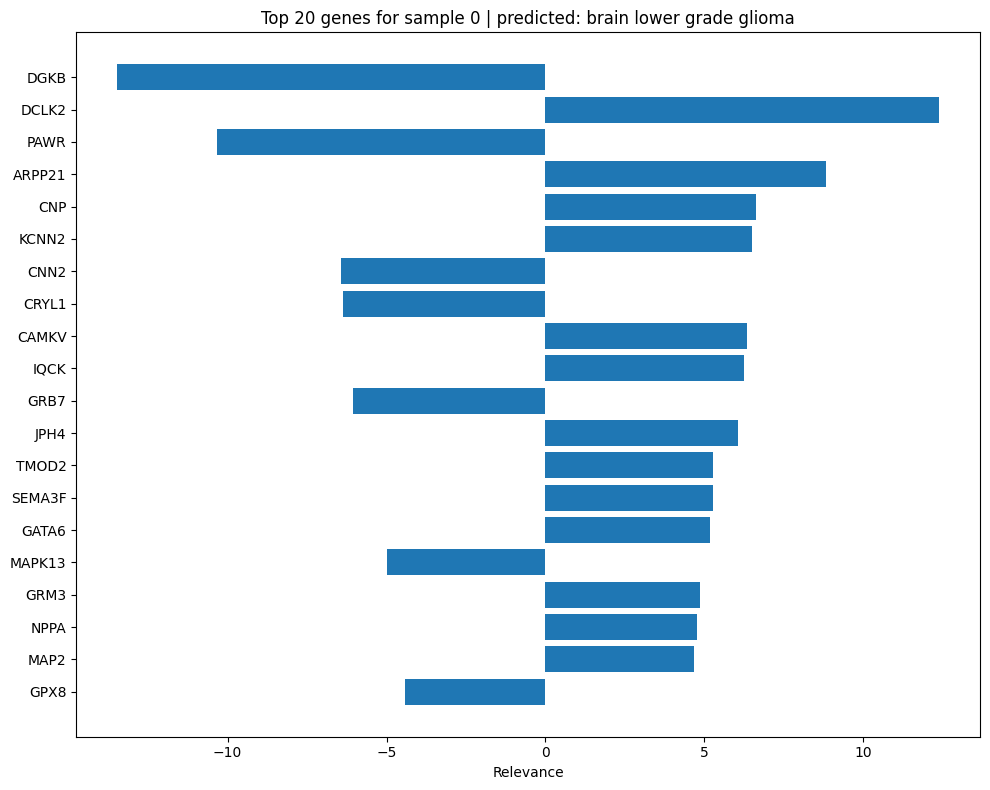

In [57]:
top_n = 20
plot_df = gene_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["gene"], plot_df["relevance"])
plt.xlabel("Relevance")
plt.title(f"Top {top_n} genes for sample {sample_idx} | predicted: {class_mapping[pred_class]}")
plt.tight_layout()
plt.show()


## Wizualizacja grafu z podświetleniem najważniejszych genów

Najpierw buduję podgraf z top-k genami i ich sąsiadami, potem koloruję węzły według znaku relevancji.


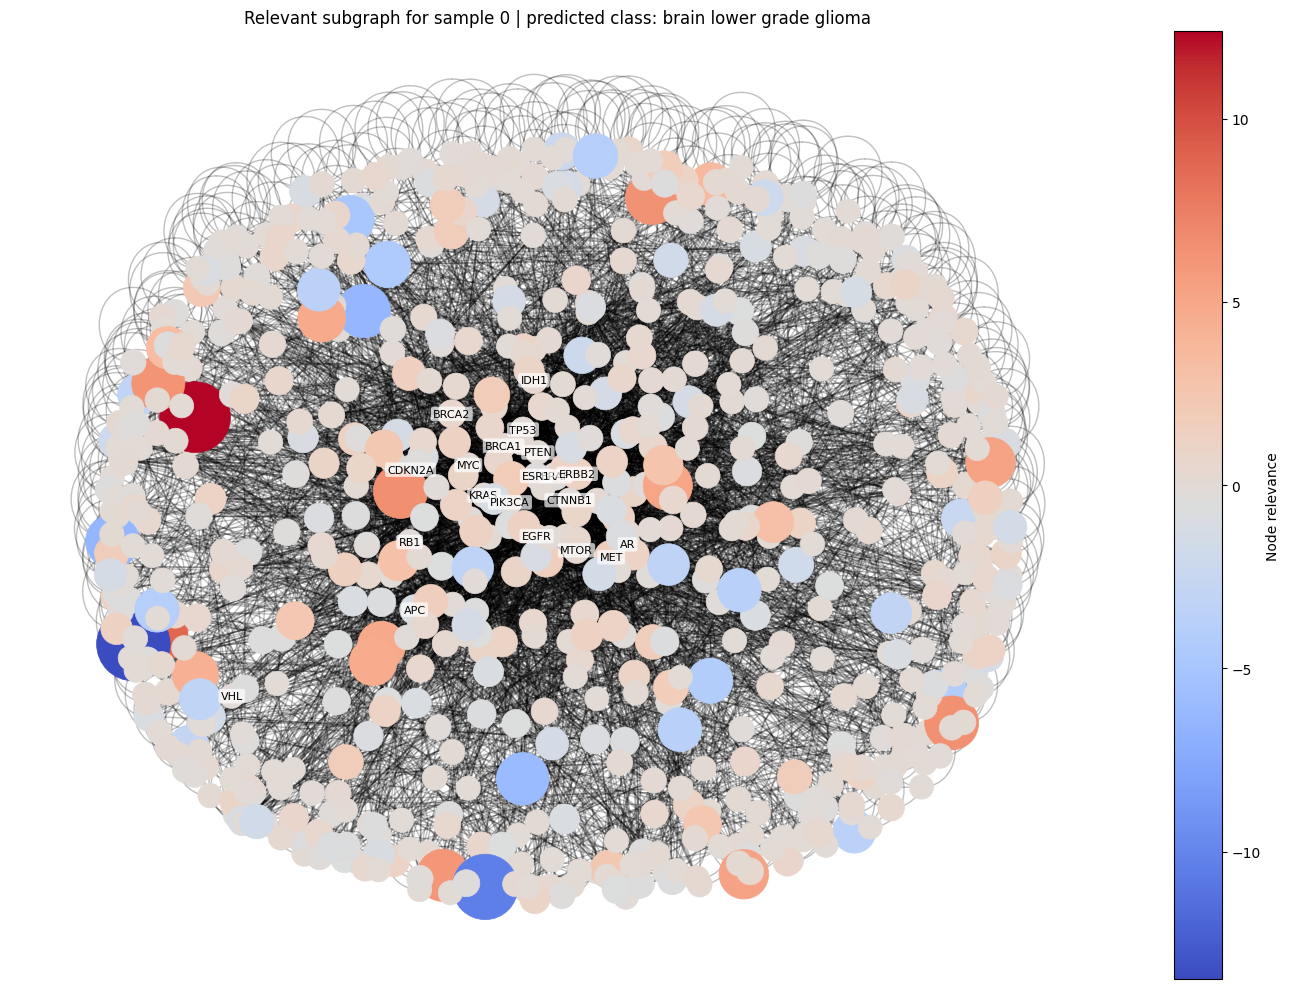

In [58]:
def build_subgraph(edge_index: torch.Tensor, selected_nodes: set[int]) -> nx.Graph:
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    g = nx.Graph()
    g.add_nodes_from(selected_nodes)
    for u, v in zip(src, dst):
        if u in selected_nodes or v in selected_nodes:
            g.add_edge(u, v)
    return g

top_k = 20
top_nodes = gene_df.head(top_k).index.tolist()
selected_nodes = set(top_nodes)


src = sample_data.edge_index[0].tolist()
dst = sample_data.edge_index[1].tolist()

for u, v in zip(src, dst):
    if u in selected_nodes or v in selected_nodes:
        selected_nodes.add(u)
        selected_nodes.add(v)

subgraph = build_subgraph(sample_data.edge_index.cpu(), selected_nodes)

node_values = {i: float(relevance[i]) for i in subgraph.nodes()}
node_sizes = [300 + 2500 * abs(node_values[n]) / (np.max(np.abs(relevance)) + 1e-8) for n in subgraph.nodes()]
node_colors = [node_values[n] for n in subgraph.nodes()]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, seed=SEED, k=0.8)

nodes = nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    linewidths=0.5
)
nx.draw_networkx_edges(subgraph, pos, alpha=0.25, width=1.0)

for n in top_nodes:
    if n in subgraph.nodes():
        x, y = pos[n]
        plt.text(x, y, genes[n], fontsize=8, ha="center", va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

plt.colorbar(nodes, label="Node relevance")
plt.title(f"Relevant subgraph for sample {sample_idx} | predicted class: {class_mapping[pred_class]}")
plt.axis("off")
plt.tight_layout()
plt.show()